In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [11]:
#R,P,S
A = torch.tensor([
    [ 0.0, -1.0,  1.0],  
    [ 1.0,  0.0, -1.0], 
    [-1.0,  1.0,  0.0], 
], dtype=torch.float32)

In [14]:
def sigma_self_play(N: int) -> torch.Tensor:
    Sigma = torch.full((N, N), 1.0 / N)
    return Sigma

def sigma_strategic_cycle() -> torch.Tensor:
    N = 3
    Sigma = torch.zeros(N, N)
    Sigma[0, 1] = 1.0
    Sigma[1, 2] = 1.0
    Sigma[2, 0] = 1.0
    return Sigma

def sigma_fictitious_play(N: int) -> torch.Tensor:
    Sigma = torch.zeros(N, N)
    for i in range(1, N):
        Sigma[i, :i] = 1.0 / float(i)
    return Sigma

In [15]:
class NeuPLNet(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int, num_slots: int, sigma_emb_dim: int = 16):
        super().__init__()
        self.num_slots = num_slots

        self.sigma_emb = nn.Embedding(num_slots, sigma_emb_dim)

        #Encoder
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        # Memory 
        self.gru = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, batch_first=True)

        # Policy head
        self.pi_head = nn.Sequential(
            nn.Linear(hidden_dim + sigma_emb_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3)  # 3 actions: R,P,S
        )

        # Value head baseline
        self.v_head = nn.Sequential(
            nn.Linear(hidden_dim + sigma_emb_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, obs_seq: torch.Tensor, sigma_idx: torch.Tensor, h0=None):
        B, T, _ = obs_seq.shape
        z = self.encoder(obs_seq.reshape(B * T, -1)).reshape(B, T, -1)  # (B,T,H)

        out, hT = self.gru(z, h0)  # out: (B,T,H)
        h_last = out[:, -1, :]     # (B,H)

        s = self.sigma_emb(sigma_idx)  # (B, E)
        feat = torch.cat([h_last, s], dim=-1)

        logits = self.pi_head(feat)      # (B,3)
        value = self.v_head(feat).squeeze(-1)  # (B,)
        return logits, value, hT



In [17]:
def play_rps_episode(net: NeuPLNet, i: int, j: int, device="cpu"):

    obs = torch.zeros(1, 1, 1, device=device)  # (B=1, T=1, obs_dim=1)
    sigma_i = torch.tensor([i], dtype=torch.long, device=device)
    sigma_j = torch.tensor([j], dtype=torch.long, device=device)

    # policy i acts using σ_i
    logits_i, v_i, _ = net(obs, sigma_i)
    dist_i = torch.distributions.Categorical(logits=logits_i)
    a_i = dist_i.sample()
    logp_i = dist_i.log_prob(a_i)

    # opponent policy j acts using σ_j (same net, different conditioning)
    logits_j, _, _ = net(obs, sigma_j)
    dist_j = torch.distributions.Categorical(logits=logits_j)
    a_j = dist_j.sample()

    r_i = A[a_i.item(), a_j.item()].to(device)  # scalar tensor
    return logp_i, v_i, r_i, a_i.item(), a_j.item()


In [18]:
def abr_update(net: NeuPLNet, Sigma: torch.Tensor, i: int, steps: int, episodes_per_step: int,
               opt: optim.Optimizer, value_coef=0.5, entropy_coef=0.01, device="cpu"):

    Sigma_i = Sigma[i].to(device)
    if Sigma_i.sum().item() == 0.0:
        # sink policy: no opponents; skip training
        return

    opp_dist = torch.distributions.Categorical(probs=Sigma_i / Sigma_i.sum())

    for _ in range(steps):
        logps, values, rewards, entropies = [], [], [], []

        for _ in range(episodes_per_step):
            j = int(opp_dist.sample().item())
            logp_i, v_i, r_i, _, _ = play_rps_episode(net, i=i, j=j, device=device)

            # entropy for exploration
            # recreate dist for entropy (small overhead, but clear)
            obs = torch.zeros(1, 1, 1, device=device)
            logits_i, _, _ = net(obs, torch.tensor([i], dtype=torch.long, device=device))
            dist_i = torch.distributions.Categorical(logits=logits_i)
            ent = dist_i.entropy()

            logps.append(logp_i)
            values.append(v_i)
            rewards.append(r_i)
            entropies.append(ent)

        logps = torch.stack(logps)         # (E,)
        values = torch.stack(values)       # (E,)
        rewards = torch.stack(rewards)     # (E,)
        entropies = torch.stack(entropies)

        # advantage
        adv = rewards.detach() - values
        policy_loss = -(logps * adv.detach()).mean()

        # value regression
        value_loss = 0.5 * (rewards - values).pow(2).mean()

        # entropy bonus
        entropy_loss = -entropies.mean()

        loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()


In [19]:
def unique_rows(Sigma: torch.Tensor):
    rows = []
    reps = []
    for i in range(Sigma.shape[0]):
        r = Sigma[i].cpu().numpy().round(6)
        if not any(np.allclose(r, rr) for rr in rows):
            rows.append(r)
            reps.append(i)
    return reps

In [21]:
def train_neupl(
    Sigma: torch.Tensor,
    outer_iters: int = 200,
    abr_steps: int = 5,
    episodes_per_step: int = 256,
    lr: float = 3e-3,
    seed: int = 0,
    device: str = "cpu",
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    N = Sigma.shape[0]
    net = NeuPLNet(obs_dim=1, hidden_dim=64, num_slots=N).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)

    # track each slot's mixed strategy over time
    history = {i: [] for i in range(N)}

    for it in range(outer_iters):
        reps = unique_rows(Sigma)

        # For each unique σ_i: ABR update
        for i in reps:
            abr_update(
                net=net,
                Sigma=Sigma,
                i=i,
                steps=abr_steps,
                episodes_per_step=episodes_per_step,
                opt=opt,
                device=device
            )

        # log current policy distributions
        with torch.no_grad():
            obs = torch.zeros(1, 1, 1, device=device)
            for i in range(N):
                logits, _, _ = net(obs, torch.tensor([i], dtype=torch.long, device=device))
                probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
                history[i].append(probs)

        if (it + 1) % 50 == 0:
            print(f"[iter {it+1}/{outer_iters}] logged policies")

    for i in range(N):
        history[i] = np.stack(history[i], axis=0)  # (T,3)
    return net, history


In [28]:
S_VERT = np.array([0.0, 0.0])
P_VERT = np.array([1.0, 0.0])
R_VERT = np.array([0.5, np.sqrt(3) / 2])


def rps_to_xy(p_rps: np.ndarray):
    """
    Map an RPS mixed strategy p = [pR, pP, pS] to 2D coords in an equilateral triangle.
    """
    pR, pP, pS = float(p_rps[0]), float(p_rps[1]), float(p_rps[2])
    xy = pS * S_VERT + pP * P_VERT + pR * R_VERT
    return xy[0], xy[1]


def plot_simplex(ax, title=None):
    tri = np.vstack([S_VERT, P_VERT, R_VERT, S_VERT])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=2)

    ax.text(S_VERT[0] - 0.03, S_VERT[1] - 0.03, "S", fontsize=12)
    ax.text(P_VERT[0] + 0.01, P_VERT[1] - 0.03, "P", fontsize=12)
    ax.text(R_VERT[0] - 0.01, R_VERT[1] + 0.02, "R", fontsize=12)

    if title is not None:
        ax.set_title(title, fontsize=14)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.06, 1.06)
    ax.set_ylim(-0.06, R_VERT[1] + 0.08)


def scatter_trajectory(ax, traj: np.ndarray, alpha=0.85, s=10):
    """
    traj: (T, 3) array of probabilities [pR, pP, pS]
    Colors from red (early) -> green (late).
    """
    T = traj.shape[0]
    xs, ys = zip(*[rps_to_xy(traj[t]) for t in range(T)])
    colors = plt.cm.RdYlGn(np.linspace(0, 1, T))
    ax.scatter(xs, ys, c=colors, s=s, alpha=alpha)


def scatter_multiple(ax, trajectories, alpha=0.35, s=8):
    """
    trajectories: list of (T,3) arrays
    """
    for traj in trajectories:
        scatter_trajectory(ax, traj, alpha=alpha, s=s)


# ---------- Example usage with your NeuPL `hist` dict ----------
# hist is returned by train_neupl(...) in the earlier code:
#   hist[i] has shape (T,3) for slot i
#
# Case A: plot one policy trajectory (e.g., self-play with N=1)
def plot_single(hist, i=0, title="Self-Play"):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_simplex(ax, title=title)
    scatter_trajectory(ax, hist[i], alpha=0.9, s=10)
    plt.tight_layout()
    plt.show()


# Case B: plot all policies in one panel (e.g., strategic cycle / fictitious play)
def plot_population(hist, indices=None, title="Population"):
    if indices is None:
        indices = sorted(hist.keys())

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_simplex(ax, title=title)
    trajectories = [hist[i] for i in indices]
    scatter_multiple(ax, trajectories, alpha=0.35, s=8)
    plt.tight_layout()
    plt.show()


# Case C: 3-panel figure like the paper (pass the 3 different histories)
def plot_three_panels(hist_self, hist_cycle, hist_fp,
                      cycle_indices=None, fp_indices=None):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Self-play: usually N=1 so plot policy 0
    plot_simplex(axes[0], title="Self-Play")
    scatter_trajectory(axes[0], hist_self[0], alpha=0.9, s=10)

    # Strategic cycle: plot all policies (or choose subset)
    plot_simplex(axes[1], title="Strategic Cycle")
    if cycle_indices is None:
        cycle_indices = sorted(hist_cycle.keys())
    scatter_multiple(axes[1], [hist_cycle[i] for i in cycle_indices], alpha=0.35, s=8)

    # Fictitious play: often skip sink policy 0 and plot 1..N-1
    plot_simplex(axes[2], title="Fictitious Play")
    if fp_indices is None:
        fp_indices = sorted(hist_fp.keys())
    scatter_multiple(axes[2], [hist_fp[i] for i in fp_indices], alpha=0.35, s=8)

    plt.tight_layout()
    plt.show()


Training Self-Play...
[iter 50/300] logged policies
[iter 100/300] logged policies
[iter 150/300] logged policies
[iter 200/300] logged policies
[iter 250/300] logged policies
[iter 300/300] logged policies


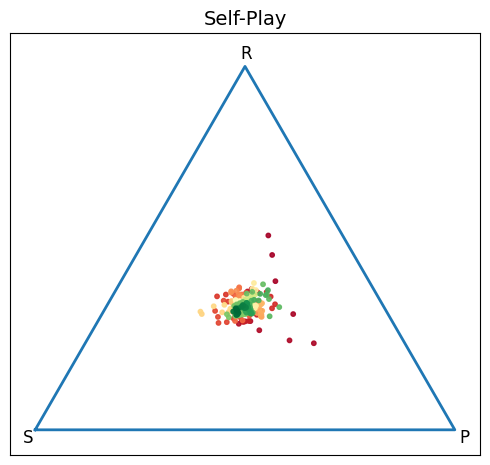


Training Strategic Cycle...
[iter 50/300] logged policies
[iter 100/300] logged policies
[iter 150/300] logged policies
[iter 200/300] logged policies
[iter 250/300] logged policies
[iter 300/300] logged policies


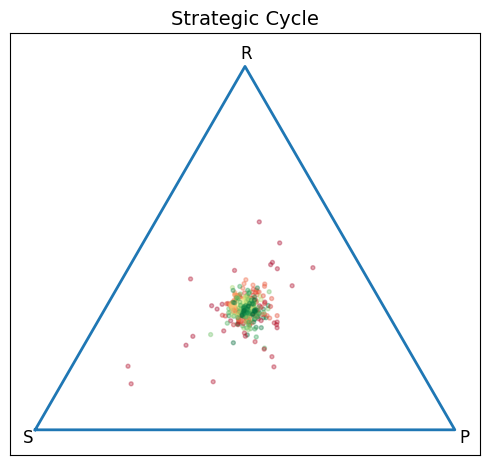


Training Fictitious Play...


In [ ]:

def main():
    device = "cpu"   

    print("\nTraining Self-Play...")
    Sigma_self = sigma_self_play(N=1)

    _, hist_self = train_neupl(
        Sigma=Sigma_self,
        outer_iters=300,
        abr_steps=5,
        episodes_per_step=256,
        lr=3e-3,
        seed=0,
        device=device,
    )

    plot_single(hist_self, i=0, title="Self-Play")

    print("\nTraining Strategic Cycle...")
    Sigma_cycle = sigma_strategic_cycle()

    _, hist_cycle = train_neupl(
        Sigma=Sigma_cycle,
        outer_iters=300,
        abr_steps=5,
        episodes_per_step=256,
        lr=3e-3,
        seed=1,
        device=device,
    )

    plot_population(hist_cycle, title="Strategic Cycle")

    print("\nTraining Fictitious Play...")
    Sigma_fp = sigma_fictitious_play(N=6)

    _, hist_fp = train_neupl(
        Sigma=Sigma_fp,
        outer_iters=400,
        abr_steps=5,
        episodes_per_step=256,
        lr=3e-3,
        seed=2,
        device=device,
    )

    plot_population(hist_fp, indices=list(range(1, 6)), title="Fictitious Play")

    print("\nPlotting combined figure...")
    plot_three_panels(
        hist_self,
        hist_cycle,
        hist_fp,
        cycle_indices=list(range(len(hist_cycle))),
        fp_indices=list(range(1, len(hist_fp))),
    )


if __name__ == "__main__":
    main()